# 01-EDA, Profiling & Cleaning (Titanic)

This notebook is the first half of the Module 2 analytics pipeline. It loads the classic Titanic dataset once, profiles it, cleans it, tells a visual data story and saves the raw data as a committed offline fallback (`titanic.csv`).

`02_modeling.ipynb` notebook continues from that same committed CSV and never reloads the dataset independently as this notebook is the single source of truth for the raw data.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 100
CHARTS_DIR = "charts"
import os
os.makedirs(CHARTS_DIR, exist_ok=True)

## Task 1-Load and profile

Loaded via `sns.load_dataset('titanic')`. This is the one and only load of the raw dataset for the whole `/analytics` module I have implemented and I immediately cache it to `titanic.csv` file and `02_modeling.ipynb` reads this same file rather than calling `sns.load_dataset` again.

In [ ]:
df = sns.load_dataset("titanic")

df.to_csv("titanic.csv", index=False)

print("shape:", df.shape)
df.head()

shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_pct = (df.isna().mean() * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Columns with missing values (% missing):")
missing_pct

Columns with missing values (% missing):


deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
dtype: float64

### Missing value strategy (threshold rule)

- Here are the Measured missing percentages: `deck` = 77.22%, `age` = 19.87%, `embarked` = 0.22%, `embark_town` = 0.22%. Now I am applying the rules provided (If `<5%` then drop rows, `5%–30%` then impute, and an explicit call for anything higher):

- `age` (19.87%, is falling in the 5–30% band), not impute with the column median (robust to  the right-skewed fare like tail some ages have, and a standard numeric-imputation  choice).
- `embarked` (0.22%) and `embark_town` (0.22%), both under 5% so dropping those rows only 2 rows are affected as dropping loses negligible data and avoids inventing a  boarding port.
- `deck` (77.22%) is far too high for imputation. So I am dropping the column rather than encode "missing" as its own category keeping a mostly empty column adds noise.

In [6]:
df_clean = df.drop(columns=["deck"]).copy()
df_clean = df_clean.dropna(subset=["embarked", "embark_town"])

age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

print(f"age median used for imputation: {age_median}")
print("Remaining missing values after cleaning:", int(df_clean.isna().sum().sum()))
print("df_clean shape:", df_clean.shape)


age median used for imputation: 28.0
Remaining missing values after cleaning: 0
df_clean shape: (889, 14)


## Task 2-Univariate analysis: `age` and `fare`

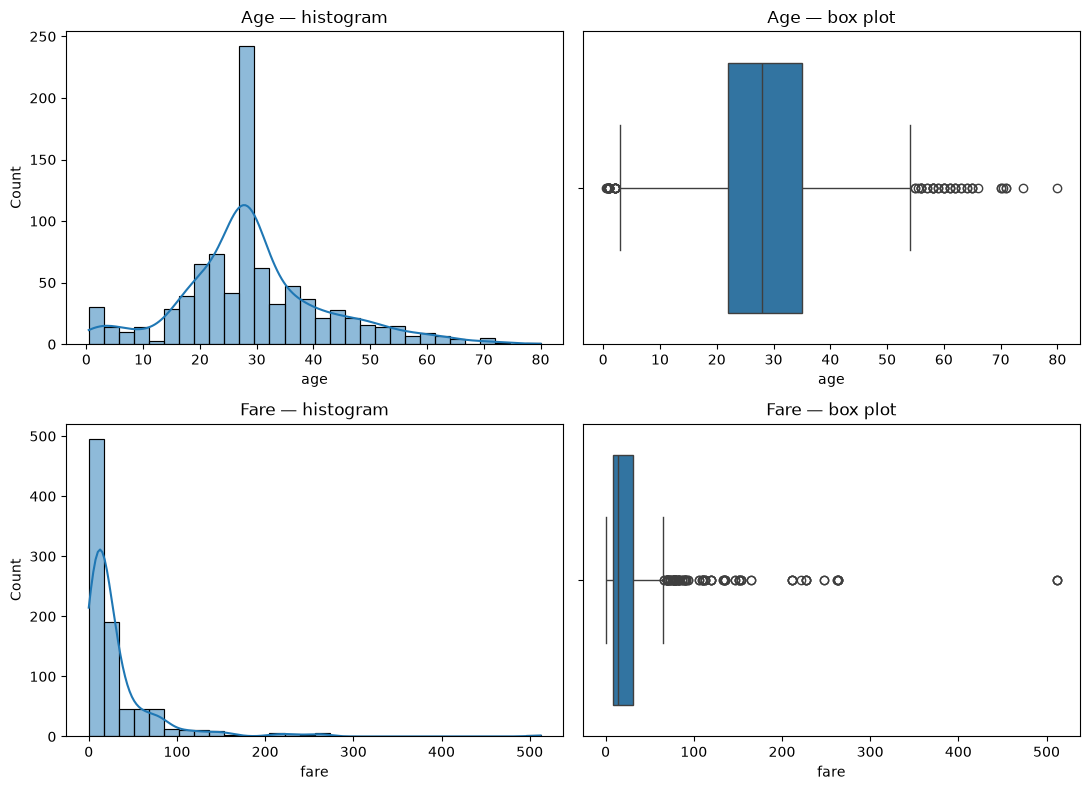

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.histplot(df_clean["age"], bins=30, kde=True, ax=axes[0, 0]).set_title("Age-histogram")
sns.boxplot(x=df_clean["age"], ax=axes[0, 1]).set_title("Age-box plot")
sns.histplot(df_clean["fare"], bins=30, kde=True, ax=axes[1, 0]).set_title("Fare-histogram")
sns.boxplot(x=df_clean["fare"], ax=axes[1, 1]).set_title("Fare-box plot")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/01_univariate_age_fare.png")
plt.show()


In [8]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper

for col in ["age", "fare"]:
    n_out, lower, upper = iqr_outliers(df_clean[col])
    print(f"{col}: {n_out} IQR outlier(s)  (bounds: [{lower:.2f}, {upper:.2f}])")


age: 65 IQR outlier(s)  (bounds: [2.50, 54.50])
fare: 114 IQR outlier(s)  (bounds: [-26.76, 65.66])


In [9]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]
print(f"fare mean = {fare_mean:.2f}, median = {fare_median:.2f}, mode = {fare_mode:.2f}")


fare mean = 32.10, median = 14.45, mode = 8.05


Skewness conclusion: for `fare`, mean (32.10) > median (14.45) > mode (8.05). This ordering mean pulled well above the median, which sits above the mode and it is the signature of a right-skewed (positively skewed) distribution. Most passengers paid low fares (third class was the majority), while a small number of first class passengers paid very high fares.

## Task 2-Bivariate analysis via boolean masking

In [ ]:
# (a) calculating the Survival rate by sex.
male_rate = df_clean.loc[df_clean["sex"] == "male", "survived"].mean()
female_rate = df_clean.loc[df_clean["sex"] == "female", "survived"].mean()
print(f"Survival rate — male:   {male_rate:.2%}")
print(f"Survival rate — female: {female_rate:.2%}")

Survival rate — male:   18.89%
Survival rate — female: 74.04%


In [ ]:
# (b) Now calculating the Survival rate by pclass
for p in sorted(df_clean["pclass"].unique()):
    rate = df_clean.loc[df_clean["pclass"] == p, "survived"].mean()
    print(f"Survival rate — pclass {p}: {rate:.2%}")

Survival rate — pclass 1: 62.62%
Survival rate — pclass 2: 47.28%
Survival rate — pclass 3: 24.24%


In [ ]:
# (c) Now the Survival rate by sex AND pclass together
for sex in ["female", "male"]:
    for p in sorted(df_clean["pclass"].unique()):
        mask = (df_clean["sex"] == sex) & (df_clean["pclass"] == p)
        rate = df_clean.loc[mask, "survived"].mean()
        print(f"Survival rate — sex={sex:6s} pclass={p}: {rate:.2%}")

Survival rate — sex=female pclass=1: 96.74%
Survival rate — sex=female pclass=2: 92.11%
Survival rate — sex=female pclass=3: 50.00%
Survival rate — sex=male   pclass=1: 36.89%
Survival rate — sex=male   pclass=2: 15.74%
Survival rate — sex=male   pclass=3: 13.54%


## Correlation matrix (6 numeric columns)

Restricted to exactly `survived, pclass, age, sibsp, parch, fare`-`adult_male` and `alone` are excluded as they are derived/redundant flags rather than independent measured features.

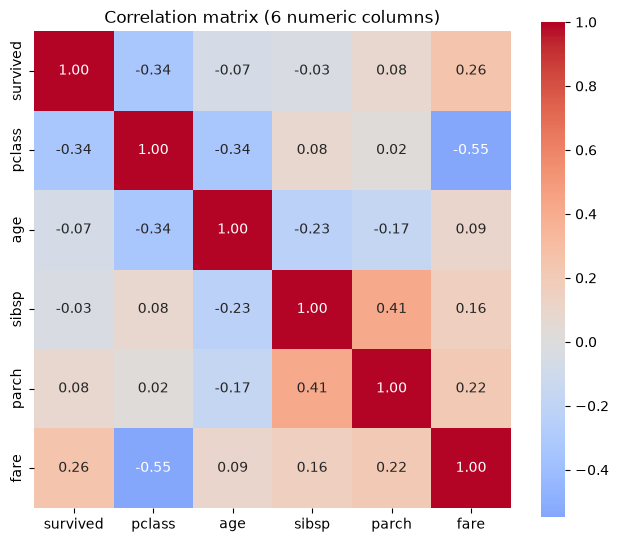

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


In [ ]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix (6 numeric columns)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/02_correlation_heatmap.png")
plt.show()
corr

In [ ]:
pairs = []
for i, a in enumerate(corr_cols):
    for b in corr_cols[i + 1:]:
        pairs.append((a, b, corr.loc[a, b]))
pairs.sort(key=lambda t: abs(t[2]), reverse=True)
print("Ranked off-diagonal pairs by |correlation|:")
for a, b, r in pairs:
    print(f"  {a:9s} <-> {b:9s}: {r:+.3f}")

Ranked off-diagonal pairs by |correlation|:
  pclass    <-> fare     : -0.548
  sibsp     <-> parch    : +0.415
  pclass    <-> age      : -0.337
  survived  <-> pclass   : -0.336
  survived  <-> fare     : +0.255
  age       <-> sibsp    : -0.233
  parch     <-> fare     : +0.218
  age       <-> parch    : -0.171
  sibsp     <-> fare     : +0.161
  age       <-> fare     : +0.094
  survived  <-> parch    : +0.083
  pclass    <-> sibsp    : +0.082
  survived  <-> age      : -0.070
  survived  <-> sibsp    : -0.034
  pclass    <-> parch    : +0.017


Two strongest correlations:

1. `pclass` and `fare`: r = −0.55 shows the strongest relationship in the matrix. Lower `pclass` numbers (1st class) go with much higher fares, which is definitional (ticket class is priced), and this is the main channel through which `pclass` and `fare` both separately correlate with `survived`.
2. `sibsp` and `parch`: r = +0.41 shows passengers travelling with siblings/spouses also tend to be travelling with parents/children. Here both are proxies for the same underlying "travelling with family vs. alone" factor rather than two independent signals. We use this to build a combined `family_size` feature in the data-story charts below.

## Task 3-Multivariate data story

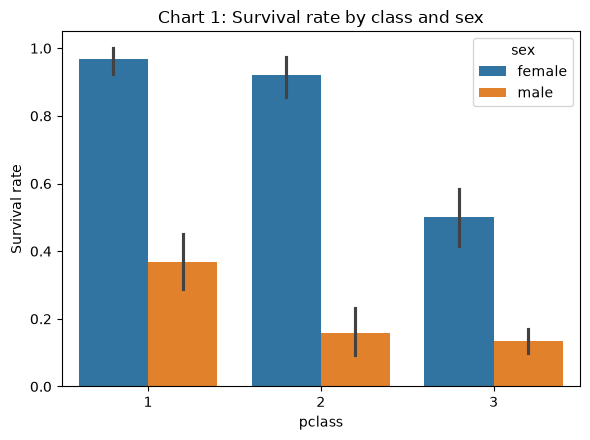

In [ ]:
plt.figure(figsize=(6, 4.5))
sns.barplot(data=df_clean, x="pclass", y="survived", hue="sex")
plt.title("Chart 1: Survival rate by class and sex")
plt.ylabel("Survival rate")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/03_survival_by_class_sex.png")
plt.show()

Interpretation (Chart 1): Sex and class combine, they don't just add. Female survival rate is at or above 92% in 1st/2nd class and still 50% in 3rd class, while male survival collapses to 13–16% in 2nd/3rd class and only reaches 37% in 1st class.

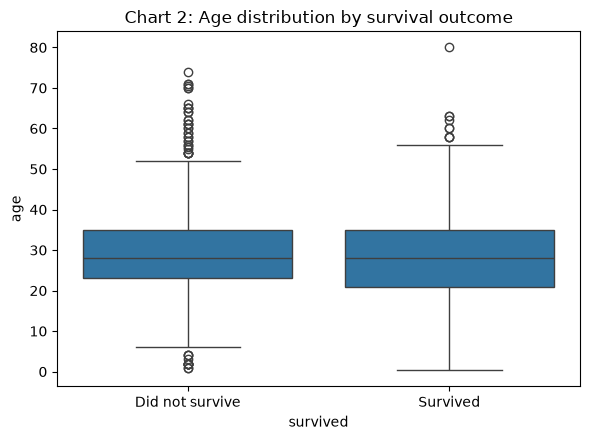

In [ ]:
plt.figure(figsize=(6, 4.5))
sns.boxplot(data=df_clean, x="survived", y="age")
plt.xticks([0, 1], ["Did not survive", "Survived"])
plt.title("Chart 2: Age distribution by survival outcome")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/04_age_by_survival.png")
plt.show()

Interpretation (Chart 2): The median age is only slightly lower for survivors, but survivors show a visibly longer lower whisker/more low-age outliers,  very young children were preferentially saved.

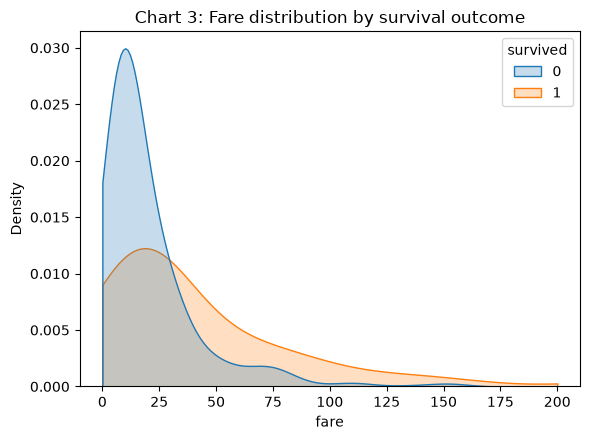

In [ ]:
plt.figure(figsize=(6, 4.5))
sns.kdeplot(data=df_clean, x="fare", hue="survived", common_norm=False, fill=True, clip=(0, 200))
plt.title("Chart 3: Fare distribution by survival outcome")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/05_fare_by_survival.png")
plt.show()

Interpretation (Chart 3): Survivors' fare distribution is shifted noticeably to the right of non-survivors', a much larger share of non-survivors paid low (<£20) fares. Since `fare` correlates strongly with `pclass` (−0.55, the strongest pair above), this chart is largely re-confirming the class effect from Chart 1 through a continuous variable higher fare (better class/location on the ship) tracked with better survival odds.

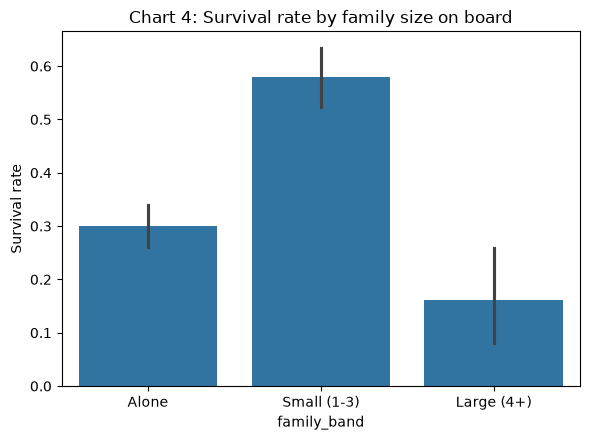

,mean,count
family_band,,
Alone,0.300935,535
Small (1-3),0.578767,292
Large (4+),0.161290,62


In [ ]:
family_size = df_clean["sibsp"] + df_clean["parch"]
family_band = pd.cut(
    family_size, bins=[-1, 0, 3, 20], labels=["Alone", "Small (1-3)", "Large (4+)"]
)
plot_df = df_clean.assign(family_band=family_band)

plt.figure(figsize=(6, 4.5))
sns.barplot(data=plot_df, x="family_band", y="survived",
            order=["Alone", "Small (1-3)", "Large (4+)"])
plt.title("Chart 4: Survival rate by family size on board")
plt.ylabel("Survival rate")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/06_survival_by_family_size.png")
plt.show()

plot_df.groupby("family_band", observed=True)["survived"].agg(["mean", "count"])

Interpretation (Chart 4): The relationship with family size is non-monotonic. Passengers travelling alone survived only 30% of the time, small
families (1–3 relatives) survived 58% of the time which is the best outcome of the three groups while large families (4+) fared worst at 16%. A plausible story: solo travellers (often 3rd-classmen) had nobody to coordinate with, small families could stay together and get priority as a unit, while large families were harder to keep together and evacuate before lifeboats filled or launched.

Exploratory standardization check (age & fare)

This is a pure EDA-stage sanity check on the full cleaned DataFrame. It does not feed into the modeling pipeline in `02_modeling.ipynb`, which performs its own train-only scaling to avoid leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler

before = df_clean[["age", "fare"]].agg(["mean", "std"])
print("Before standardization:")
print(before)

scaler = StandardScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(df_clean[["age", "fare"]]),
    columns=["age_z", "fare_z"],
)

after = scaled.agg(["mean", "std"])
print("\nAfter standardization (z-score):")
print(after)

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After standardization (z-score):
             age_z        fare_z
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


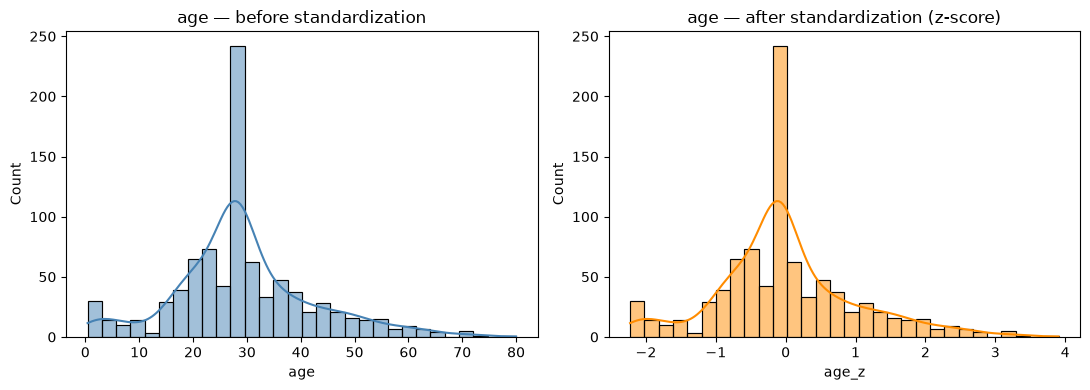

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_clean["age"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("age — before standardization")
sns.histplot(scaled["age_z"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("age — after standardization (z-score)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/07_standardization_check.png")
plt.show()

Both `age_z` and `fare_z` have (approximately) mean 0 and standard deviation 1, after the z-score transform, confirming the standardization worked as expected. Shown above as printed summary statistics and an overlaid before/after histogram for `age`.

---
Next: `02_modeling.ipynb` reads the committed `titanic.csv` (the same raw file loaded from Task 1 above) and continues into the predictive modeling pipeline which is Part B.